# Power Market Dispatch & Fuel Switching Analytics

**Data source:** U.S.(EIA), 2025 EIA-923

### Objective
Analyze how natural gas and coal generation, plant efficiency, and delivered fuel economics varied during 2025.

### Questions
1. How did gas and coal generation change through the year?
2. What were the weighted average plant heat rates?
3. How did delivered gas and coal fuel costs vary?
4. Is there an observable association between relative fuel costs and the gas share of generation?




## 1. Import libraries

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Find the project root automatically.
current = Path.cwd().resolve()
ROOT = None

for candidate in [current, *current.parents]:
    if (candidate / "data" / "raw").is_dir():
        ROOT = candidate
        break

if ROOT is None:
    raise FileNotFoundError(
        "Project folder not found. Open this notebook from the "
        "Power_Market_Dispatch_Fuel_Switching project folder. "
        "The project must contain data/raw/."
    )

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
CHARTS = ROOT / "outputs" / "charts"

PROCESSED.mkdir(parents=True, exist_ok=True)
CHARTS.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Raw data folder:", RAW)

raw_files = list(RAW.glob("*.xlsx"))
print("Excel files found:", [f.name for f in raw_files])


Project root: C:\Users\karedi Deepak\Downloads\Power_Market_Dispatch_Fuel_Switching_JUPYTER
Raw data folder: C:\Users\karedi Deepak\Downloads\Power_Market_Dispatch_Fuel_Switching_JUPYTER\data\raw
Excel files found: ['EIA923_Schedules_2_3_4_5_M_12_2025_Final.xlsx', 'EIA923_Schedules_6_7_NU_SourceNDisposition_2025_Final.xlsx', 'EIA923_Schedule_8_Annual_Envir_Infor_2025_Final.xlsx']


## 2. Load the EIA-923 generation and fuel data

The first workbook contains plant-level generation and electric fuel-consumption information.

In [2]:
# Load the EIA-923 generation workbook

generation_matches = list(
    RAW.glob("EIA923_Schedules_2_3_4_5_M_12_2025_Final*.xlsx")
)

if not generation_matches:
    raise FileNotFoundError(
        "The EIA-923 generation workbook was not found in:\n"
        f"{RAW}\n\n"
        "Make sure the original EIA-923 Excel workbook is inside "
        "the project's data/raw/ folder."
    )

generation_file = generation_matches[0]

generation_raw = pd.read_excel(
    generation_file,
    sheet_name="Page 1 Generation and Fuel Data",
    header=5
)

# Standardize column names ONCE.
generation_raw.columns = (
    generation_raw.columns
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("Workbook:", generation_file.name)
print("Rows:", len(generation_raw))
print("Columns:", len(generation_raw.columns))
print("Required columns found:",
      all(c in generation_raw.columns for c in [
          "MER Fuel Type Code",
          "Combined Heat And Power Plant",
          "EIA Sector Number"
      ]))


Workbook: EIA923_Schedules_2_3_4_5_M_12_2025_Final.xlsx
Rows: 18889
Columns: 97
Required columns found: True


## 3. Clean and define the analysis sample

For this portfolio project, the analysis uses:

- Natural gas (`NG`) and coal (`COL`)
- Non-CHP plants
- EIA sectors 1 and 2
- Positive generation and positive electric fuel consumption
- Heat-rate values between 3 and 25 MMBtu/MWh as a simple outlier screen

This keeps the analysis focused and makes the methodology easy to explain in an interview.


In [3]:
df = generation_raw.copy()

df = df[df["MER Fuel Type Code"].isin(["NG", "COL"])].copy()
df = df[df["Combined Heat And Power Plant"].eq("N")].copy()
df = df[df["EIA Sector Number"].isin([1, 2])].copy()

df["fuel_group"] = df["MER Fuel Type Code"].map({
    "NG": "Natural Gas",
    "COL": "Coal"
})

df["Net Generation (Megawatthours)"] = pd.to_numeric(
    df["Net Generation (Megawatthours)"], errors="coerce"
)
df["Elec Fuel Consumption MMBtu"] = pd.to_numeric(
    df["Elec Fuel Consumption MMBtu"], errors="coerce"
)

df = df[
    (df["Net Generation (Megawatthours)"] > 0) &
    (df["Elec Fuel Consumption MMBtu"] > 0)
].copy()

df["heat_rate_mmbtu_mwh"] = (
    df["Elec Fuel Consumption MMBtu"] /
    df["Net Generation (Megawatthours)"]
)

df = df[df["heat_rate_mmbtu_mwh"].between(3, 25)].copy()

df = df.rename(columns={
    "Plant Id": "plant_id",
    "Plant Name": "plant_name",
    "Plant State": "state",
    "Net Generation (Megawatthours)": "net_generation_mwh",
    "Elec Fuel Consumption MMBtu": "electric_fuel_mmbtu"
})

plant = df[
    [
        "plant_id",
        "plant_name",
        "state",
        "fuel_group",
        "net_generation_mwh",
        "electric_fuel_mmbtu",
        "heat_rate_mmbtu_mwh"
    ]
].copy()

print("Records after cleaning:", len(plant))
plant.head()


Records after cleaning: 1736


,plant_id,plant_name,state,fuel_group,net_generation_mwh,electric_fuel_mmbtu,heat_rate_mmbtu_mwh
4,3,Barry,AL,Natural Gas,"7,540,378.000",75192884,9.972
5,3,Barry,AL,Coal,"632,117.510",7274465,11.508
6,3,Barry,AL,Natural Gas,"394,390.490",4953851,12.561
10,9,Copper,TX,Natural Gas,"27,839.999",486438,17.473
12,10,Greene County,AL,Natural Gas,"31,502.906",463624,14.717


## 4. Plant-level heat-rate analysis

Heat rate is calculated as:

**Heat rate = fuel energy consumed (MMBtu) / electricity generated (MWh)**

A lower heat rate means less fuel energy is required per MWh of electricity generated.

In [4]:
weighted_heat_rate = (
    plant.groupby("fuel_group")
    .apply(
        lambda g: np.average(
            g["heat_rate_mmbtu_mwh"],
            weights=g["net_generation_mwh"]
        ),
        include_groups=False
    )
    .rename("weighted_heat_rate_mmbtu_mwh")
    .reset_index()
)

weighted_heat_rate


,fuel_group,weighted_heat_rate_mmbtu_mwh
0,Coal,10.660
1,Natural Gas,10.243


## 5. Monthly generation

The EIA-923 workbook reports separate monthly `Netgen` fields. We reshape those fields into a monthly dataset.

In [5]:
source = generation_raw.copy()

source = source[source["MER Fuel Type Code"].isin(["NG", "COL"])].copy()
source = source[source["Combined Heat And Power Plant"].eq("N")].copy()
source = source[source["EIA Sector Number"].isin([1, 2])].copy()

source["fuel_group"] = source["MER Fuel Type Code"].map({
    "NG": "Natural Gas",
    "COL": "Coal"
})

# Find the actual EIA monthly Netgen columns.
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_columns = {}

for month in month_names:
    matches = [
        col for col in source.columns
        if "netgen" in str(col).lower()
        and month.lower() in str(col).lower()
    ]

    if not matches:
        raise KeyError(
            f"Could not find the Netgen column for {month}. "
            f"Available columns include:\n{source.columns.tolist()}"
        )

    month_columns[month] = matches[0]

print("Monthly generation columns:")
for month, column in month_columns.items():
    print(f"{month}: {column}")

monthly_rows = []

for month_number, month_name in enumerate(month_names, start=1):
    column = month_columns[month_name]

    temp = source[["fuel_group", column]].copy()
    temp["generation_mwh"] = pd.to_numeric(
        temp[column], errors="coerce"
    ).fillna(0)

    grouped = (
        temp.groupby("fuel_group")["generation_mwh"]
        .sum()
        .reset_index()
    )

    grouped["month"] = month_name
    grouped["month_number"] = month_number
    monthly_rows.append(grouped)

monthly_generation_long = pd.concat(
    monthly_rows,
    ignore_index=True
)

monthly_generation = (
    monthly_generation_long
    .pivot(
        index=["month_number", "month"],
        columns="fuel_group",
        values="generation_mwh"
    )
    .reset_index()
    .rename_axis(None, axis=1)
    .sort_values("month_number")
    .reset_index(drop=True)
)

for fuel in ["Natural Gas", "Coal"]:
    if fuel not in monthly_generation.columns:
        monthly_generation[fuel] = 0.0

print("Monthly generation calculated successfully.")
monthly_generation


Monthly generation columns:
Jan: Netgen January
Feb: Netgen February
Mar: Netgen March
Apr: Netgen April
May: Netgen May
Jun: Netgen June
Jul: Netgen July
Aug: Netgen August
Sep: Netgen September
Oct: Netgen October
Nov: Netgen November
Dec: Netgen December
Monthly generation calculated successfully.


,month_number,month,Coal,Natural Gas
0,1,Jan,"77,983,283.538","136,290,849.288"
1,2,Feb,"57,395,366.101","113,862,751.745"
2,3,Mar,"45,755,952.408","100,153,927.883"
3,4,Apr,"42,498,640.493","97,727,691.419"
4,5,May,"44,855,390.086","117,310,283.502"
5,6,Jun,"59,982,218.151","145,315,409.340"
6,7,Jul,"74,158,921.925","177,930,610.002"
7,8,Aug,"64,518,049.090","170,241,114.009"
8,9,Sep,"53,891,740.123","146,986,941.960"
9,10,Oct,"49,938,302.701","123,567,806.612"


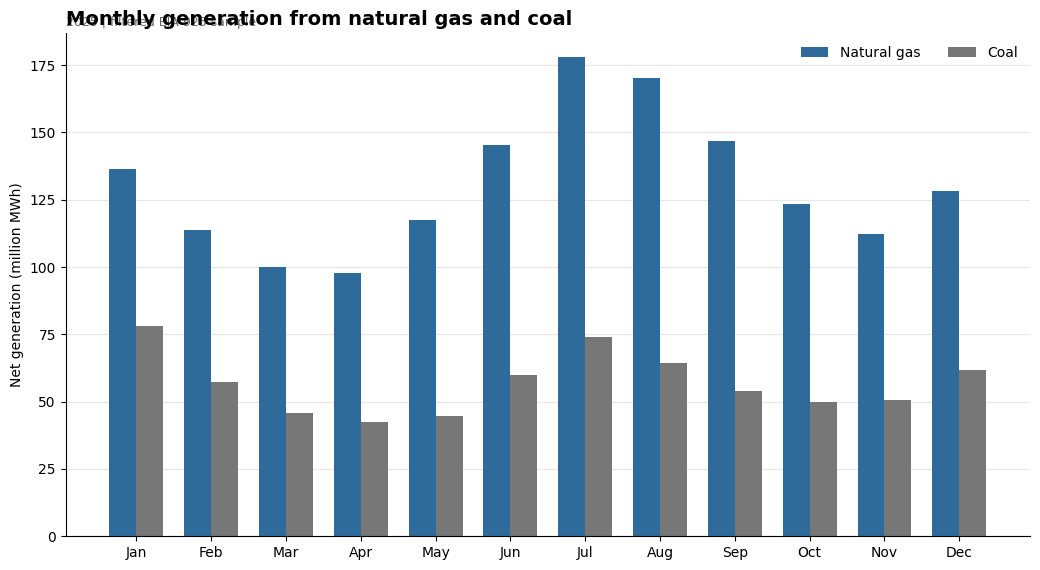

In [6]:
# Portfolio chart: monthly generation

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10
})

x = np.arange(len(monthly_generation))
width = 0.36

fig, ax = plt.subplots(figsize=(10.5, 5.8))

ax.bar(
    x - width/2,
    monthly_generation["Natural Gas"] / 1e6,
    width,
    label="Natural gas",
    color="#2F6B9A"
)

ax.bar(
    x + width/2,
    monthly_generation["Coal"] / 1e6,
    width,
    label="Coal",
    color="#777777"
)

ax.set_xticks(x)
ax.set_xticklabels(monthly_generation["month"])
ax.set_ylabel("Net generation (million MWh)")
ax.set_title(
    "Monthly generation from natural gas and coal",
    loc="left",
    weight="bold"
)
ax.text(
    0, 1.015,
    "2025 | filtered EIA-923 sample",
    transform=ax.transAxes,
    fontsize=9,
    color="#666666"
)
ax.grid(axis="y", color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()


## 6. Load fuel receipts and calculate delivered fuel cost

The EIA-923 fuel-receipts table contains fuel quantity, heat content, and reported fuel cost. The project calculates a monthly weighted average delivered cost.

**Caveat:** fuel receipts represent deliveries, so the delivered cost is not necessarily the exact same-month fuel cost of electricity generation.

In [8]:
# Load EIA-923 fuel receipts and costs

receipts_raw = pd.read_excel(
    generation_file,
    sheet_name="Page 5 Fuel Receipts and Costs",
    header=4
)

# Clean column names once
receipts_raw.columns = (
    receipts_raw.columns
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("Fuel receipts columns:")
print(receipts_raw.columns.tolist())

# Keep Natural Gas and Coal
receipts = receipts_raw[
    receipts_raw["FUEL_GROUP"].astype(str).str.strip()
    .isin(["Natural Gas", "Coal"])
].copy()

# Convert numeric fields
receipts["QUANTITY"] = pd.to_numeric(
    receipts["QUANTITY"],
    errors="coerce"
)

receipts["Average Heat Content"] = pd.to_numeric(
    receipts["Average Heat Content"],
    errors="coerce"
)

receipts["FUEL_COST"] = pd.to_numeric(
    receipts["FUEL_COST"],
    errors="coerce"
)

# Convert reported fuel cost to USD/MMBtu
receipts["fuel_cost_usd_mmbtu"] = (
    receipts["FUEL_COST"] / 100
)

# Calculate received MMBtu
receipts["received_mmbtu"] = (
    receipts["QUANTITY"] *
    receipts["Average Heat Content"]
)

# Remove invalid records
receipts = receipts[
    (receipts["received_mmbtu"] > 0) &
    (receipts["fuel_cost_usd_mmbtu"] > 0)
].copy()

# Cost × quantity weighting
receipts["weighted_cost"] = (
    receipts["fuel_cost_usd_mmbtu"] *
    receipts["received_mmbtu"]
)

# Monthly weighted fuel cost
monthly_prices = (
    receipts
    .groupby(
        ["YEAR", "MONTH", "FUEL_GROUP"],
        as_index=False
    )
    .agg(
        total_received_mmbtu=("received_mmbtu", "sum"),
        weighted_cost=("weighted_cost", "sum")
    )
)

monthly_prices["fuel_cost_usd_mmbtu"] = (
    monthly_prices["weighted_cost"] /
    monthly_prices["total_received_mmbtu"]
)

print("Fuel-price calculation completed.")

monthly_prices.head()

Fuel receipts columns:
['YEAR', 'MONTH', 'Plant Id', 'Plant Name', 'Plant State', 'Purchase Type', 'Contract Expiration Date', 'ENERGY_SOURCE', 'FUEL_GROUP', 'Coalmine Type', 'Coalmine State', 'Coalmine County', 'Coalmine Msha Id', 'Coalmine Name', 'SUPPLIER', 'QUANTITY', 'Average Heat Content', 'Average Sulfur Content', 'Average Ash Content', 'Average Mercury Content', 'FUEL_COST', 'Regulated', 'Operator Name', 'Operator Id', 'Reporting Frequency', 'Primary Transportation Mode', 'Secondary Transportation Mode', 'Natural Gas Supply Contract Type', 'Natural Gas Delivery Contract Type', 'Moisture Content', 'Chlorine Content', 'Balancing Authority Code']
Fuel-price calculation completed.


,YEAR,MONTH,FUEL_GROUP,total_received_mmbtu,weighted_cost,fuel_cost_usd_mmbtu
0,2025,1,Coal,"447,734,502.117","1,093,596,946.508",2.443
1,2025,1,Natural Gas,"590,317,747.409","3,257,118,030.874",5.518
2,2025,2,Coal,"401,305,739.806","999,103,267.926",2.490
3,2025,2,Natural Gas,"483,173,266.194","2,340,760,111.180",4.845
4,2025,3,Coal,"471,481,273.874","1,189,591,197.667",2.523


In [9]:
price_pivot = (
    monthly_prices
    .pivot(
        index=["YEAR", "MONTH"],
        columns="FUEL_GROUP",
        values="fuel_cost_usd_mmbtu"
    )
    .reset_index()
    .rename(columns={
        "Natural Gas": "gas_price_usd_mmbtu",
        "Coal": "coal_price_usd_mmbtu"
    })
)

price_pivot["month_number"] = price_pivot["MONTH"]
price_pivot["month"] = pd.to_datetime(
    price_pivot["month_number"], format="%m"
).dt.strftime("%b")

price_pivot.head()


FUEL_GROUP,YEAR,MONTH,coal_price_usd_mmbtu,gas_price_usd_mmbtu,month_number,month
0,2025,1,2.443,5.518,1,Jan
1,2025,2,2.490,4.845,2,Feb
2,2025,3,2.523,4.427,3,Mar
3,2025,4,2.542,3.880,4,Apr
4,2025,5,2.549,3.581,5,May


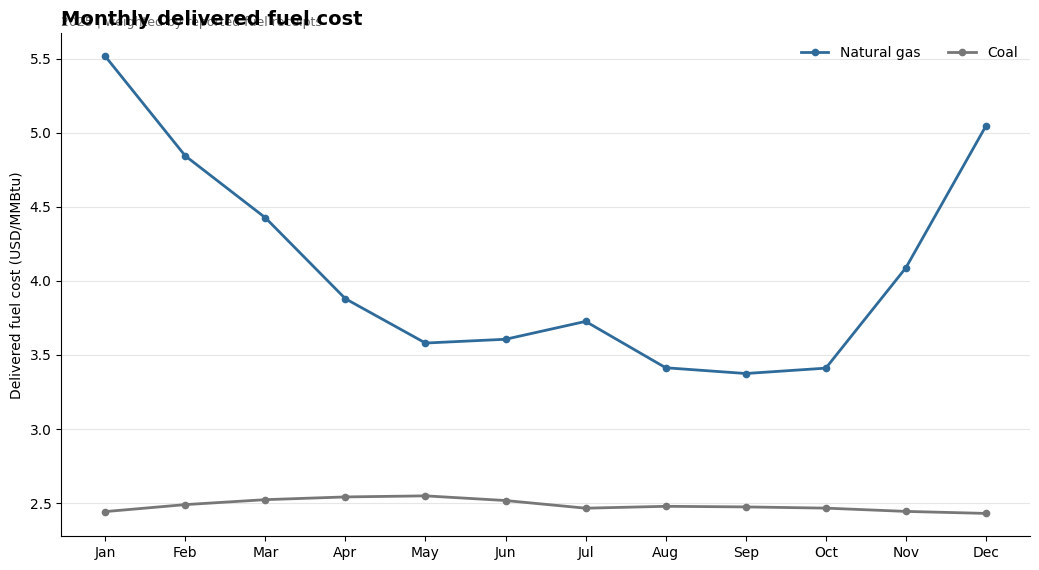

In [10]:
# Portfolio chart: delivered fuel cost

fig, ax = plt.subplots(figsize=(10.5, 5.8))

ax.plot(
    price_pivot["month_number"],
    price_pivot["gas_price_usd_mmbtu"],
    marker="o",
    markersize=4.5,
    linewidth=2,
    label="Natural gas",
    color="#2F6B9A"
)

ax.plot(
    price_pivot["month_number"],
    price_pivot["coal_price_usd_mmbtu"],
    marker="o",
    markersize=4.5,
    linewidth=2,
    label="Coal",
    color="#777777"
)

ax.set_xticks(price_pivot["month_number"])
ax.set_xticklabels(price_pivot["month"])
ax.set_ylabel("Delivered fuel cost (USD/MMBtu)")
ax.set_title(
    "Monthly delivered fuel cost",
    loc="left",
    weight="bold"
)
ax.text(
    0, 1.015,
    "2025 | weighted by reported fuel receipts",
    transform=ax.transAxes,
    fontsize=9,
    color="#666666"
)
ax.grid(axis="y", color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()


## 7. Combine generation and fuel economics

In [11]:
market = monthly_generation.merge(
    price_pivot[
        [
            "month_number",
            "month",
            "gas_price_usd_mmbtu",
            "coal_price_usd_mmbtu"
        ]
    ],
    on=["month_number", "month"],
    how="inner"
)

market["total_gas_coal_generation"] = (
    market["Natural Gas"] +
    market["Coal"]
)

market["gas_generation_share"] = (
    market["Natural Gas"] /
    market["total_gas_coal_generation"]
)

market["coal_generation_share"] = (
    market["Coal"] /
    market["total_gas_coal_generation"]
)

market["gas_coal_price_ratio"] = (
    market["gas_price_usd_mmbtu"] /
    market["coal_price_usd_mmbtu"]
)

market


,month_number,month,Coal,Natural Gas,gas_price_usd_mmbtu,coal_price_usd_mmbtu,total_gas_coal_generation,gas_generation_share,coal_generation_share,gas_coal_price_ratio
0,1,Jan,"77,983,283.538","136,290,849.288",5.518,2.443,"214,274,132.826",0.636,0.364,2.259
1,2,Feb,"57,395,366.101","113,862,751.745",4.845,2.490,"171,258,117.846",0.665,0.335,1.946
2,3,Mar,"45,755,952.408","100,153,927.883",4.427,2.523,"145,909,880.291",0.686,0.314,1.755
3,4,Apr,"42,498,640.493","97,727,691.419",3.880,2.542,"140,226,331.912",0.697,0.303,1.527
4,5,May,"44,855,390.086","117,310,283.502",3.581,2.549,"162,165,673.588",0.723,0.277,1.405
5,6,Jun,"59,982,218.151","145,315,409.340",3.606,2.517,"205,297,627.491",0.708,0.292,1.433
6,7,Jul,"74,158,921.925","177,930,610.002",3.727,2.466,"252,089,531.927",0.706,0.294,1.512
7,8,Aug,"64,518,049.090","170,241,114.009",3.414,2.478,"234,759,163.099",0.725,0.275,1.378
8,9,Sep,"53,891,740.123","146,986,941.960",3.375,2.474,"200,878,682.083",0.732,0.268,1.364
9,10,Oct,"49,938,302.701","123,567,806.612",3.411,2.466,"173,506,109.313",0.712,0.288,1.383


## 8. Fuel economics and generation mix

The next analysis asks whether months with a higher gas-to-coal delivered-cost ratio also had a different gas share of generation.

This is an **association**, not evidence that fuel price differences alone caused the generation change.

In [12]:
X = sm.add_constant(
    market["gas_coal_price_ratio"]
)

y = market["gas_generation_share"]

model = sm.OLS(y, X).fit()

print(model.summary())


                             OLS Regression Results                             
Dep. Variable:     gas_generation_share   R-squared:                       0.911
Model:                              OLS   Adj. R-squared:                  0.902
Method:                   Least Squares   F-statistic:                     102.5
Date:                  Sun, 20 Sep 2026   Prob (F-statistic):           1.42e-06
Time:                          12:37:16   Log-Likelihood:                 41.011
No. Observations:                    12   AIC:                            -78.02
Df Residuals:                        10   BIC:                            -77.05
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

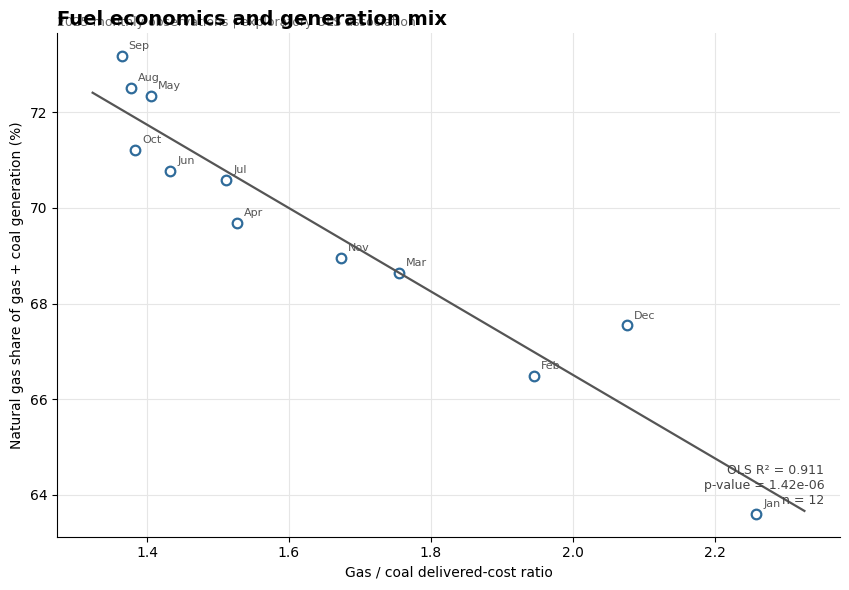

In [13]:
# Portfolio chart: regression relationship

x_values = market["gas_coal_price_ratio"].to_numpy()
y_values = (market["gas_generation_share"] * 100).to_numpy()

line_coefficients = np.polyfit(x_values, y_values, 1)
line_x = np.linspace(
    x_values.min() * 0.97,
    x_values.max() * 1.03,
    100
)
line_y = (
    line_coefficients[0] * line_x +
    line_coefficients[1]
)

fig, ax = plt.subplots(figsize=(8.6, 6.0))

ax.scatter(
    x_values,
    y_values,
    s=48,
    facecolor="white",
    edgecolor="#2F6B9A",
    linewidth=1.6
)

ax.plot(
    line_x,
    line_y,
    color="#555555",
    linewidth=1.6
)

for i, month in enumerate(market["month"]):
    ax.annotate(
        month,
        (x_values[i], y_values[i]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color="#555555"
    )

ax.set_xlabel("Gas / coal delivered-cost ratio")
ax.set_ylabel(
    "Natural gas share of gas + coal generation (%)"
)
ax.set_title(
    "Fuel economics and generation mix",
    loc="left",
    weight="bold"
)
ax.text(
    0, 1.015,
    "2025 monthly observations | exploratory OLS association",
    transform=ax.transAxes,
    fontsize=9,
    color="#666666"
)
ax.grid(color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax.text(
    0.98, 0.06,
    f"OLS R² = {model.rsquared:.3f}\n"
    f"p-value = {model.pvalues['gas_coal_price_ratio']:.2e}\n"
    f"n = {int(model.nobs)}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="#444444"
)

plt.tight_layout()
plt.show()


## 9. Key results

The values below are calculated from the actual 2025 EIA-923 data used in this project.

In [14]:
gas_generation = market["Natural Gas"].sum()
coal_generation = market["Coal"].sum()
total_generation = gas_generation + coal_generation

gas_weighted_hr = np.average(
    plant.loc[
        plant["fuel_group"].eq("Natural Gas"),
        "heat_rate_mmbtu_mwh"
    ],
    weights=plant.loc[
        plant["fuel_group"].eq("Natural Gas"),
        "net_generation_mwh"
    ]
)

coal_weighted_hr = np.average(
    plant.loc[
        plant["fuel_group"].eq("Coal"),
        "heat_rate_mmbtu_mwh"
    ],
    weights=plant.loc[
        plant["fuel_group"].eq("Coal"),
        "net_generation_mwh"
    ]
)

gas_avg_cost = np.average(
    monthly_prices.loc[
        monthly_prices["FUEL_GROUP"].eq("Natural Gas"),
        "fuel_cost_usd_mmbtu"
    ],
    weights=monthly_prices.loc[
        monthly_prices["FUEL_GROUP"].eq("Natural Gas"),
        "total_received_mmbtu"
    ]
)

coal_avg_cost = np.average(
    monthly_prices.loc[
        monthly_prices["FUEL_GROUP"].eq("Coal"),
        "fuel_cost_usd_mmbtu"
    ],
    weights=monthly_prices.loc[
        monthly_prices["FUEL_GROUP"].eq("Coal"),
        "total_received_mmbtu"
    ]
)

results = pd.DataFrame({
    "Metric": [
        "Records after cleaning",
        "Natural gas generation (million MWh)",
        "Coal generation (million MWh)",
        "Natural gas share",
        "Coal share",
        "Natural gas weighted heat rate",
        "Coal weighted heat rate",
        "Average delivered gas cost (USD/MMBtu)",
        "Average delivered coal cost (USD/MMBtu)",
        "Regression R²",
        "Regression p-value",
        "Regression observations"
    ],
    "Value": [
        len(plant),
        gas_generation / 1e6,
        coal_generation / 1e6,
        gas_generation / total_generation,
        coal_generation / total_generation,
        gas_weighted_hr,
        coal_weighted_hr,
        gas_avg_cost,
        coal_avg_cost,
        model.rsquared,
        model.pvalues["gas_coal_price_ratio"],
        int(model.nobs)
    ]
})

results


,Metric,Value
0,Records after cleaning,"1,736.000"
1,Natural gas generation (million MWh),"1,569.823"
2,Coal generation (million MWh),683.136
3,Natural gas share,0.697
4,Coal share,0.303
5,Natural gas weighted heat rate,10.243
6,Coal weighted heat rate,10.660
7,Average delivered gas cost (USD/MMBtu),4.024
8,Average delivered coal cost (USD/MMBtu),2.484
9,Regression R²,0.911
